<a href="https://colab.research.google.com/github/HafizaNoorUlSaba/langgraph/blob/Smart_Router_Agent/Smart_Router_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Install Libraries***

In [2]:
!pip install langchain langgraph typing langchain-google-genai langchain-groq


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 33.0 MB/s eta 0:00:00
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=3c5bee3a62b4f5e30666864253fb4c1b38938cdc59324fd7fb9c49a086fea3c4
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


***Import Libraries***

In [1]:


from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [2]:

import os
from google.colab import userdata

# Retrieve the API key from Colab secrets and set it as an environment variable
# Ensure you have a secret named 'GROQ_API_KEY' in Colab secrets.
groq_api_key_from_secrets = userdata.get('Groq_Api_Key')

if groq_api_key_from_secrets:
    os.environ['GROQ_API_KEY'] = groq_api_key_from_secrets
    print("GROQ_API_KEY loaded from Colab secrets.")
else:
    print("Warning: GROQ_API_KEY secret not found in Colab secrets. Please ensure it's set correctly.")

GROQ_API_KEY loaded from Colab secrets.


***Define LLM***

In [3]:
llm = ChatGroq(
    groq_api_key=os.getenv("Groq_Api_Key"),
    model_name="openai/gpt-oss-120b" # Corrected to a supported Groq model
)
model = llm

***Define the State***

In [36]:
class AgentState(TypedDict):
  user_input:str
  task:str
  response:str


***Create Router Node:***

In [37]:
def router(state: AgentState):

    text = state["user_input"].lower()

    if "summarize" in text:
        task = "summary"

    elif "translate" in text:
        task = "translation"

    elif "email" in text:
        task = "email"

    else:
        task = "general"

    return {
        "task": task
    }

***Create Summary Agent***

In [38]:
def summary_agent(state: AgentState):

    prompt = f"""
    Summarize the following text:

    {state['user_input']}
    """

    answer = llm.invoke(prompt)

    return {
        "response": answer.content
    }

***Create Translate Agent***

In [39]:
def translate_agent(state: AgentState):

    prompt = f"""
    Translate the following text to Spanish:

    {state['user_input']}
    """

    answer = llm.invoke(prompt)

    return {
        "response": answer.content
    }

***Create Email Agent***

In [40]:
def email_agent(state:AgentState):

    prompt = f"""
    Create an email from the following text:

    {state['user_input']}
    """

    answer = llm.invoke(prompt)

    return {
        "response": answer.content
    }

***General Chat***

In [41]:
def general_agent(state:AgentState):

    prompt = f"""
    Answer the following question:

    {state['user_input']}
    """

    answer = llm.invoke(prompt)

    return {
        "response": answer.content
    }

***Create graph***

In [42]:
graph = StateGraph(AgentState)

In [43]:
graph.add_node("Router", router)
graph.add_node("Summary", summary_agent)
graph.add_node("Translate", translate_agent)
graph.add_node("Email", email_agent)
graph.add_node("General", general_agent)



***Define Conditional Routing***

In [44]:
def conditional_routing(state: AgentState):
  return state["task"]

In [45]:
graph.add_conditional_edges(
    "Router",
    conditional_routing,
    {
        "summary": "Summary",
        "translation": "Translate",
        "email": "Email",
        "general": "General",
    }
)

In [46]:
graph.add_edge(START, "Router")
graph.add_edge("Summary", END)

graph.add_edge("Translate", END)

graph.add_edge("Email", END)

graph.add_edge("General", END)

***Compile***

In [47]:
app = graph.compile()

***Visualize***

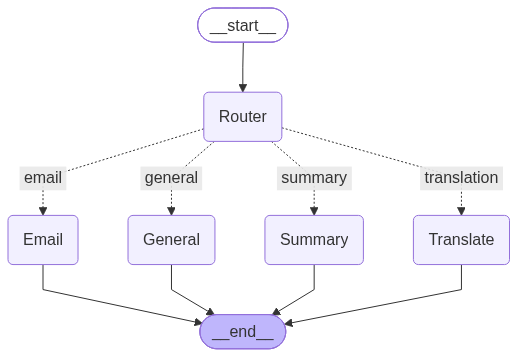

In [48]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

***Test***

In [49]:
result = app.invoke(
    {
        "user_input": "Summarize Artificial Intelligence in two lines."
    }
)

print(result["response"])

Artificial Intelligence (AI) is the field of computer science that creates systems capable of performing tasks that normally require human intelligence, such as learning, reasoning, perception, and decision‑making. By leveraging data, algorithms, and computational power, AI enables machines to adapt, predict, and interact autonomously across diverse applications.


In [53]:
result=app.invoke(
    {
        "user_input": "Translate the following text to urdu: Hello, how are you?"

    }
)
print(result['response'])

**Spanish translation**  
> Traduce el siguiente texto al urdu: Hello, how are you?

**Urdu translation**  
> Hello, how are you? → **ہیلو، آپ کیسے ہیں؟**


In [54]:
result=app.invoke(
    {
        "user_input":"Write an email for requesting for 5 days leave?"
    }
)
print(result['response'])

**Subject:** Request for 5‑Day Leave ( [Start Date] – [End Date] )

Dear [Supervisor’s Name],

I hope you are well. I am writing to request a leave of absence for five working days, from **[Start Date]** through **[End Date]**.  

The reason for this leave is **[briefly state the reason, e.g., a personal matter, a family commitment, medical appointment, etc.]**. I have ensured that my current tasks are up to date, and I will complete any pending work before my departure. I will also provide a detailed handover to [Colleague’s Name] to ensure continuity and address any urgent matters that may arise while I am away.

Please let me know if you need any additional information or if there are any concerns regarding this request. I appreciate your consideration and look forward to your approval.

Thank you for your understanding.

Best regards,

[Your Full Name]  
[Your Position]  
[Department]  
[Phone Number]  
[Email Address]  
